# Week 10 Jupyter Notebook — Clustering 1: K-Means

## Objective

This notebook applies Week 10 clustering methods to my airline delay capstone project. The main goal is to use unsupervised learning to see whether flights naturally group into different operational patterns.

For this week, I focused on:

- k-means clustering
- feature scaling
- elbow method
- Silhouette score
- distance metrics
- interpreting clusters using `DEP_DEL15` after clustering

Because k-means is unsupervised, I do not use `DEP_DEL15` as a model target. I use it after the clusters are created to understand whether some groups have higher delay risk.

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA

## 1. Load the datasets

The main data source is the Kaggle `train.csv` file from the airline delay dataset. I also try to load the BTS delay file as supporting context, but the k-means clustering mainly uses the flight-level Kaggle data.

I use a sample because clustering methods can become slow on the full airline dataset.

In [2]:
SAMPLE_SIZE = 50000
CLUSTER_SAMPLE_SIZE = 10000
RANDOM_STATE = 42

train = pd.read_csv("data/train.csv", nrows=SAMPLE_SIZE)

try:
    delay = pd.read_csv("data/Flight_delay.csv")
    print("BTS delay file shape:", delay.shape)
except FileNotFoundError:
    print("BTS delay file not found. Continuing with train.csv only.")

print("Train shape:", train.shape)
train.head()

BTS delay file shape: (484551, 29)
Train shape: (50000, 30)


,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,CARRIER_HISTORICAL,DEP_AIRPORT_HIST,DAY_HISTORICAL,DEP_BLOCK_HIST
0,7,7,0,1500-1559,3,3,26,160,American Airlines Inc.,19534,...,Chicago O'Hare International,0.00,0.0,0.0,95.0,4.25,0.237709,0.273236,0.222538,0.255479
1,4,1,0,1300-1359,4,4,63,50,SkyWest Airlines Inc.,18788,...,El Paso International,0.00,0.0,0.0,71.0,11.41,0.154651,0.121849,0.237972,0.197503
2,11,4,0,0001-0559,2,1,3,76,American Eagle Airlines Inc.,1148,...,NONE,0.00,0.0,0.0,54.0,0.45,0.117559,0.187867,0.139886,0.060327
3,3,2,0,1500-1559,7,5,14,143,Southwest Airlines Co.,7612,...,San Jose International,0.00,0.0,0.0,64.0,8.05,0.204389,0.141446,0.132868,0.202037
4,7,3,0,0800-0859,1,2,85,50,American Eagle Airlines Inc.,29376,...,Cincinnati/Northern Kentucky International,0.01,0.0,0.0,94.0,10.51,0.203263,0.193761,0.203027,0.113050


## 2. Quick EDA

Before clustering, I check the target distribution. This is not used to build the clusters, but it helps interpret the cluster results later.

If the delayed class is smaller than the non-delayed class, then a useful cluster would be one that shows a noticeably different delay rate from the overall average.

Target counts:
DEP_DEL15
0    40520
1     9480
Name: count, dtype: int64

Target percentage:
DEP_DEL15
0    81.04
1    18.96
Name: proportion, dtype: float64

Overall delay rate: 0.1896


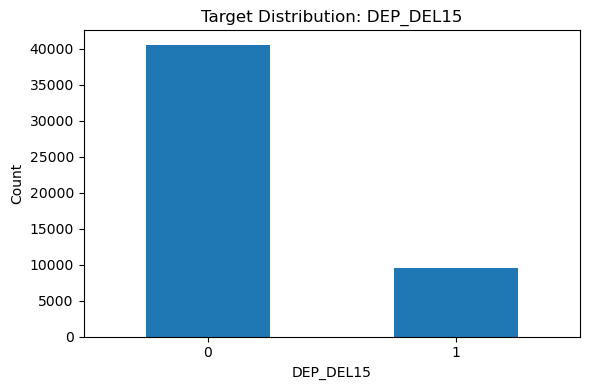

In [7]:
target = "DEP_DEL15"

print("Target counts:")
print(train[target].value_counts(dropna=False))

print("\nTarget percentage:")
print((train[target].value_counts(normalize=True, dropna=False) * 100).round(2))

overall_delay_rate = train[target].mean()
print("\nOverall delay rate:", round(overall_delay_rate, 4))

plt.figure(figsize=(6, 4))
train[target].value_counts().sort_index().plot(kind="bar")
plt.title("Target Distribution: DEP_DEL15")
plt.xlabel("DEP_DEL15")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Select clustering features

I use numeric variables from the earlier notebooks. These include time, weather, airport activity, carrier history, and historical delay features.

I do not include `DEP_DEL15` in the clustering features because clustering is unsupervised.

In [8]:
target = "DEP_DEL15"

numeric_candidates = [
    "MONTH",
    "DAY_OF_WEEK",
    "DISTANCE_GROUP",
    "SEGMENT_NUMBER",
    "CONCURRENT_FLIGHTS",
    "NUMBER_OF_SEATS",
    "AIRPORT_FLIGHTS_MONTH",
    "AIRLINE_FLIGHTS_MONTH",
    "AIRLINE_AIRPORT_FLIGHTS_MONTH",
    "AVG_MONTHLY_PASS_AIRPORT",
    "AVG_MONTHLY_PASS_AIRLINE",
    "FLT_ATTENDANTS_PER_PASS",
    "GROUND_SERV_PER_PASS",
    "PLANE_AGE",
    "LATITUDE",
    "LONGITUDE",
    "PRCP",
    "SNOW",
    "SNWD",
    "TMAX",
    "AWND",
    "CARRIER_HISTORICAL",
    "DEP_AIRPORT_HIST",
    "DAY_HISTORICAL",
    "DEP_BLOCK_HIST"
]

features = [col for col in numeric_candidates if col in train.columns]

print("Target used for interpretation:", target)
print("Number of clustering features used:", len(features))
print(features)

Target used for interpretation: DEP_DEL15
Number of clustering features used: 25
['MONTH', 'DAY_OF_WEEK', 'DISTANCE_GROUP', 'SEGMENT_NUMBER', 'CONCURRENT_FLIGHTS', 'NUMBER_OF_SEATS', 'AIRPORT_FLIGHTS_MONTH', 'AIRLINE_FLIGHTS_MONTH', 'AIRLINE_AIRPORT_FLIGHTS_MONTH', 'AVG_MONTHLY_PASS_AIRPORT', 'AVG_MONTHLY_PASS_AIRLINE', 'FLT_ATTENDANTS_PER_PASS', 'GROUND_SERV_PER_PASS', 'PLANE_AGE', 'LATITUDE', 'LONGITUDE', 'PRCP', 'SNOW', 'SNWD', 'TMAX', 'AWND', 'CARRIER_HISTORICAL', 'DEP_AIRPORT_HIST', 'DAY_HISTORICAL', 'DEP_BLOCK_HIST']


## 4. Prepare and scale the data

Feature scaling is important for k-means because k-means is distance-based. If one variable has a much larger scale than another variable, it can dominate the distance calculation.

For example, passenger counts and weather values are on very different scales. Standardizing the variables makes them more comparable.

In [9]:
# Keep only selected features and target for later interpretation.
cluster_data = train[features + [target]].copy()
cluster_data = cluster_data.dropna()

# Sample again so clustering runs faster.
if len(cluster_data) > CLUSTER_SAMPLE_SIZE:
    cluster_data = cluster_data.sample(n=CLUSTER_SAMPLE_SIZE, random_state=RANDOM_STATE)

X = cluster_data[features]
y = cluster_data[target].astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Clustering data shape:", cluster_data.shape)
print("Scaled feature matrix shape:", X_scaled.shape)
print("Delay rate in clustering sample:", round(y.mean(), 4))

Clustering data shape: (10000, 26)
Scaled feature matrix shape: (10000, 25)
Delay rate in clustering sample: 0.192


## 5. Distance metrics check

K-means uses Euclidean distance to assign observations to the nearest centroid. To show why distance metrics matter, I compare Euclidean and Manhattan distances on a small sample of scaled rows.

This is mainly a concept check. The actual k-means algorithm below uses Euclidean distance.

In [10]:
distance_sample = X_scaled[:200]

euclidean_distances = pairwise_distances(distance_sample, metric="euclidean")
manhattan_distances = pairwise_distances(distance_sample, metric="manhattan")

# Use only upper triangle values so we do not double-count pairs.
upper_triangle = np.triu_indices_from(euclidean_distances, k=1)

distance_compare = pd.DataFrame({
    "Metric": ["Euclidean", "Manhattan"],
    "Average distance": [
        euclidean_distances[upper_triangle].mean(),
        manhattan_distances[upper_triangle].mean()
    ],
    "Median distance": [
        np.median(euclidean_distances[upper_triangle]),
        np.median(manhattan_distances[upper_triangle])
    ]
})

distance_compare.round(4)

,Metric,Average distance,Median distance
0,Euclidean,7.0031,6.6487
1,Manhattan,25.3368,24.9537


## 6. Elbow method

The elbow method compares k-means inertia across different values of `k`. Inertia measures how tightly points are grouped around their assigned cluster centers.

A lower inertia is better, but inertia will almost always decrease as `k` increases. The goal is to look for the point where adding more clusters gives smaller improvements.

In [11]:
k_values = range(2, 11)
inertias = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

elbow_df = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertias
})

elbow_df

,k,Inertia
0,2,226281.857974
1,3,208698.657658
2,4,199341.387517
3,5,189607.612484
4,6,183179.911573
5,7,177128.325385
6,8,172500.306859
7,9,168056.366437
8,10,164872.226976


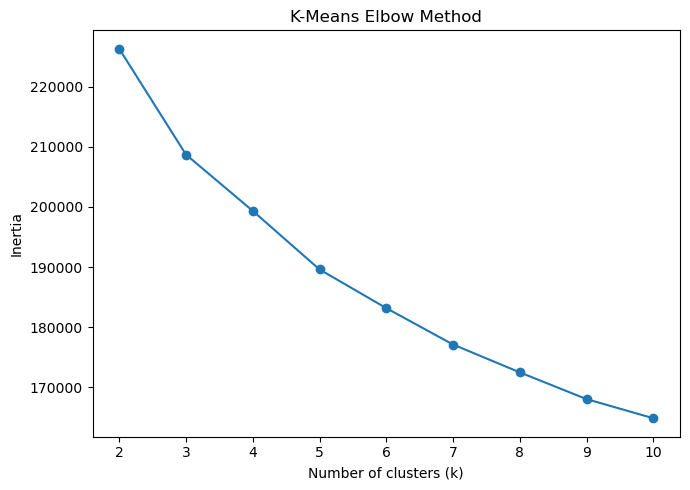

In [12]:
plt.figure(figsize=(7, 5))
plt.plot(elbow_df["k"], elbow_df["Inertia"], marker="o")
plt.title("K-Means Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

## 7. Silhouette score

The Silhouette score checks how well separated the clusters are. Scores closer to 1 mean observations fit well within their cluster and are far from other clusters.

For this project, I use the Silhouette score with the elbow method because the elbow method can be somewhat subjective.

In [13]:
silhouette_rows = []

# Silhouette score can be slow, so use a smaller sample if needed.
silhouette_sample_size = min(5000, X_scaled.shape[0])
np.random.seed(RANDOM_STATE)
silhouette_idx = np.random.choice(X_scaled.shape[0], size=silhouette_sample_size, replace=False)
X_silhouette = X_scaled[silhouette_idx]

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_silhouette)
    score = silhouette_score(X_silhouette, labels)
    silhouette_rows.append({"k": k, "Silhouette Score": score})

silhouette_df = pd.DataFrame(silhouette_rows)
silhouette_df.sort_values("Silhouette Score", ascending=False).round(4)

,k,Silhouette Score
2,4,0.1107
1,3,0.1092
0,2,0.1072
4,6,0.0971
3,5,0.0971
8,10,0.0946
7,9,0.0914
5,7,0.0903
6,8,0.0850


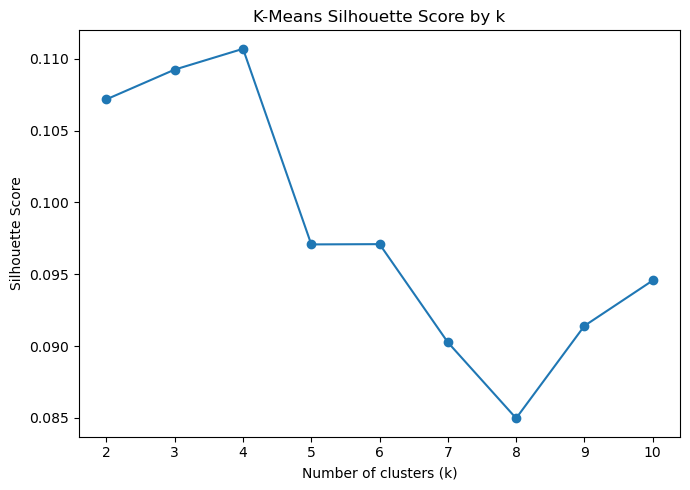

In [14]:
plt.figure(figsize=(7, 5))
plt.plot(silhouette_df["k"], silhouette_df["Silhouette Score"], marker="o")
plt.title("K-Means Silhouette Score by k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

## 8. Fit final k-means model

I choose the final number of clusters based on the elbow method and Silhouette score. The code below automatically chooses the `k` with the highest Silhouette score, but this can be adjusted if the elbow plot suggests a more useful value.

In [15]:
best_k = int(silhouette_df.sort_values("Silhouette Score", ascending=False).iloc[0]["k"])
print("Selected k based on highest Silhouette score:", best_k)

final_kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_scaled)

cluster_data = cluster_data.copy()
cluster_data["cluster"] = cluster_labels

print("Cluster counts:")
print(cluster_data["cluster"].value_counts().sort_index())

Selected k based on highest Silhouette score: 4
Cluster counts:
cluster
0    1567
1    3328
2    2905
3    2200
Name: count, dtype: int64


## 9. Interpret clusters using delay rate

After creating the clusters, I compare each cluster's delay rate to the overall delay rate.

This helps answer whether the unsupervised groups line up with meaningful airline delay risk patterns.

In [16]:
cluster_summary = (
    cluster_data
    .groupby("cluster")
    .agg(
        count=(target, "size"),
        delay_rate=(target, "mean"),
        avg_prcp=("PRCP", "mean") if "PRCP" in cluster_data.columns else (target, "mean"),
        avg_dep_airport_hist=("DEP_AIRPORT_HIST", "mean") if "DEP_AIRPORT_HIST" in cluster_data.columns else (target, "mean"),
        avg_dep_block_hist=("DEP_BLOCK_HIST", "mean") if "DEP_BLOCK_HIST" in cluster_data.columns else (target, "mean"),
        avg_carrier_hist=("CARRIER_HISTORICAL", "mean") if "CARRIER_HISTORICAL" in cluster_data.columns else (target, "mean")
    )
    .reset_index()
)

cluster_summary["delay_rate_diff_from_overall"] = cluster_summary["delay_rate"] - overall_delay_rate
cluster_summary.round(4)

,cluster,count,delay_rate,avg_prcp,avg_dep_airport_hist,avg_dep_block_hist,avg_carrier_hist,delay_rate_diff_from_overall
0,0,1567,0.2093,0.0965,0.1861,0.2066,0.1831,0.0197
1,1,3328,0.2004,0.1103,0.1862,0.1948,0.1916,0.0108
2,2,2905,0.1907,0.1040,0.1903,0.1933,0.1978,0.0011
3,3,2200,0.1686,0.1017,0.1886,0.1668,0.1803,-0.0210


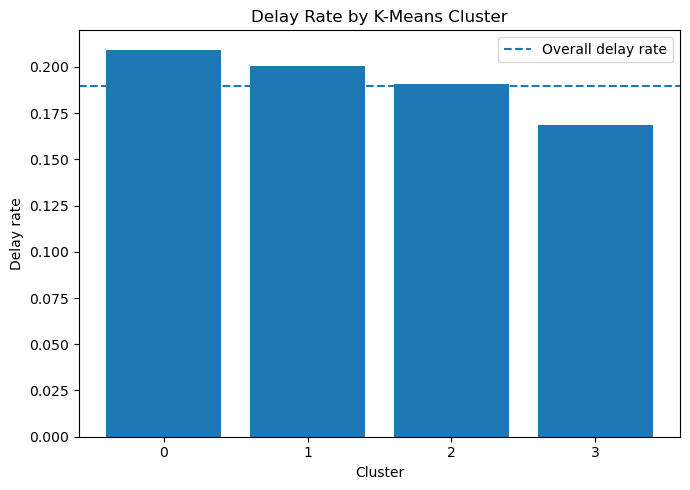

In [17]:
plt.figure(figsize=(7, 5))
plt.bar(cluster_summary["cluster"].astype(str), cluster_summary["delay_rate"])
plt.axhline(overall_delay_rate, linestyle="--", label="Overall delay rate")
plt.title("Delay Rate by K-Means Cluster")
plt.xlabel("Cluster")
plt.ylabel("Delay rate")
plt.legend()
plt.tight_layout()
plt.show()

## 10. PCA visualization of clusters

Because the model uses many features, I use PCA only for visualization. This reduces the scaled feature set to two dimensions so the cluster pattern can be plotted.

The PCA plot should not be treated as the full clustering result, but it helps visualize how separated the clusters are.

Explained variance by PC1 and PC2:
[0.1375 0.1052]


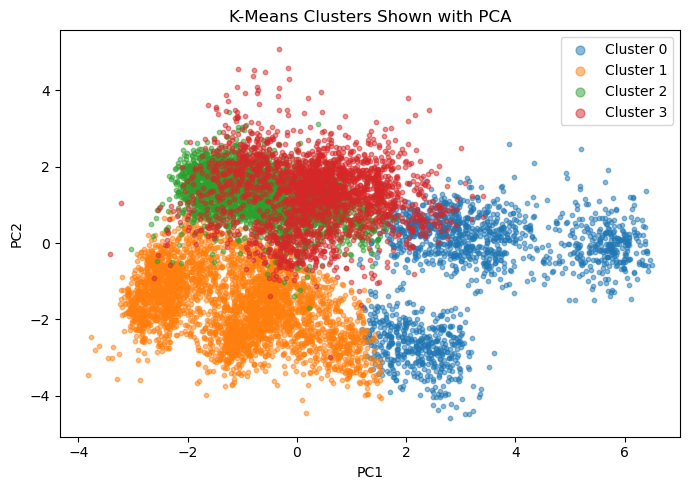

In [18]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": cluster_labels,
    "DEP_DEL15": y.values
})

print("Explained variance by PC1 and PC2:")
print(pca.explained_variance_ratio_.round(4))

plt.figure(figsize=(7, 5))
for cluster in sorted(pca_df["cluster"].unique()):
    temp = pca_df[pca_df["cluster"] == cluster]
    plt.scatter(temp["PC1"], temp["PC2"], s=10, alpha=0.5, label=f"Cluster {cluster}")

plt.title("K-Means Clusters Shown with PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(markerscale=2)
plt.tight_layout()
plt.show()

## Week 10 conclusion

K-means was useful because it gave another way to look at the airline delay data without using the target variable directly. Instead of predicting delayed or not delayed, it grouped flights based on similar operational, weather, airport, carrier, and historical delay patterns.

Feature scaling was one of the most important steps. Since k-means depends on distance, unscaled variables with larger numeric ranges could dominate the clustering. Scaling helped make the distance calculation more balanced across features.

The elbow method and Silhouette score helped choose a reasonable number of clusters. The clusters were then compared by delay rate. If one cluster had a higher delay rate than the overall sample, that supported the idea that the data contains system-level patterns related to delay risk. This connects back to the capstone question because it shows that some groups of flights appear to have higher operational stress than others.

The main limitation is that k-means assumes roughly circular clusters and uses Euclidean distance. Real airline delay patterns may be more complex than that. Still, k-means was useful for exploratory modeling and for finding groups that could be described by delay history, airport conditions, weather, and flight sequence.